In [1]:
using Piccolo
using CairoMakie
using QuantumToolbox
using DifferentialEquations

In [2]:
σ_ = ComplexF64[0 1; 0 0]
σx = ComplexF64[0 1; 1 0]
σz = ComplexF64[1 0; 0 -1]

function Commutator(H, ρ)
    return H * ρ - ρ * H
end

function Anti_Commutator(H, ρ)
    return H * ρ + ρ * H
end

function inner_D(ρ, σ)
    return σ * ρ * σ' - 0.5 * Anti_Commutator(σ' * σ, ρ)
end

function D_1(ρ, T1::Real, σ)
    return 1/T1 * inner_D(ρ, σ)
end

function D_ϕ(ρ, Tϕ::Real, σ)
    return 1/(2* Tϕ) * inner_D(ρ, σ)
end

D_ϕ (generic function with 1 method)

In [7]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
Δ = - 2π * 400 / 1000

function gaussian_curve(t, Tg, N)
   Ω0 = π / (Tg * (super_duper_value - ℯ^(-2))) / 2
    μ = Tg / 2
    σ = Tg / 4
    function f(t)
        return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)) .- ℯ .^ (-2))
    end

    function f_prime(t)
        return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)))  .* ((μ .- t)/σ^2)
    end

    E_π = f(t)
    Ė_π = f_prime(t)
    return E_π, Ė_π
end

function drag_gaussian(t, Tg, N)
    E_π, Ė_π = gaussian_curve(t, Tg, N)
    E_x = E_π .+ ((λ^2-4)/(8Δ^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128Δ^4 * E_π .^ 5)
    E_y = -Ė_π ./ Δ + ((33(λ^2-2)/24Δ^3) * E_π .^2 .* Ė_π)
    return E_x, E_y
end

drag_gaussian (generic function with 1 method)

In [8]:
function Hamiltonian(t, Tg, chooser; N = 100)
    H0 = ComplexF64[0 0; 0 0]
    if chooser == 1
        return  H0 .+ gaussian_curve(t, Tg, N)[1] .* σx # / 2
    elseif chooser == 2
        return  H0 .+ drag_gaussian(t, Tg, N)[1] .* σx # / 2
    end
end

function ρ̇!(drho, rho, p, t)
    H = Hamiltonian(t, Tg, 1)
    drho .= (- im * Commutator(H, rho) + D_1(rho, T1, σ_) + D_ϕ(rho, Tϕ, σz))
end


function ρ̇!_DRAG(drho, rho, p, t)
    H = Hamiltonian(t, Tg, 2)
    drho .= (- im * Commutator(H, rho) + D_1(rho, T1, σ_) + D_ϕ(rho, Tϕ, σz))
end

ρ̇!_DRAG (generic function with 1 method)

In [9]:

initial_state = ComplexF64[1; 0]
ρ0 = initial_state * initial_state'

target_state = ComplexF64[0; 1]
target_ρ = target_state * target_state'

function result(time, chooser)
    t_span = (0.0, time)
    if chooser == 1
        prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    elseif chooser == 2
        prob = ODEProblem(ρ̇!_DRAG, ρ0,adaptive=false, t_span)
    end
    sol = solve(prob, Tsit5(), dt = 0.1)
    states = sol.u
    zero_pop = zeros(length(states))
    one_pop = zeros(length(states))
    for (i,ρ) in enumerate(states)
        zero_pop[i] = ρ[1,1]
        one_pop[i] = ρ[2,2]
    end
    return [states, zero_pop, one_pop]
end

function Uhlmann_Fidelity(ρ_target, ρ_final)
    real((tr(sqrt(sqrt(ρ_target) * ρ_final * sqrt(ρ_target))))^2)
end



function calc_population(states)
    populations = []
    for i in range(1, size(states)[1])
        push!(populations, real(initial_state' * states[i] * initial_state))
        end
    return populations
end

function calc_infidelity(states)
    infidelity = []
    for i in range(1, size(states)[1])
        push!(infidelity, 1 .- real(Uhlmann_Fidelity(target_ρ, states[i])))
        end
    return infidelity
end

calc_infidelity (generic function with 1 method)

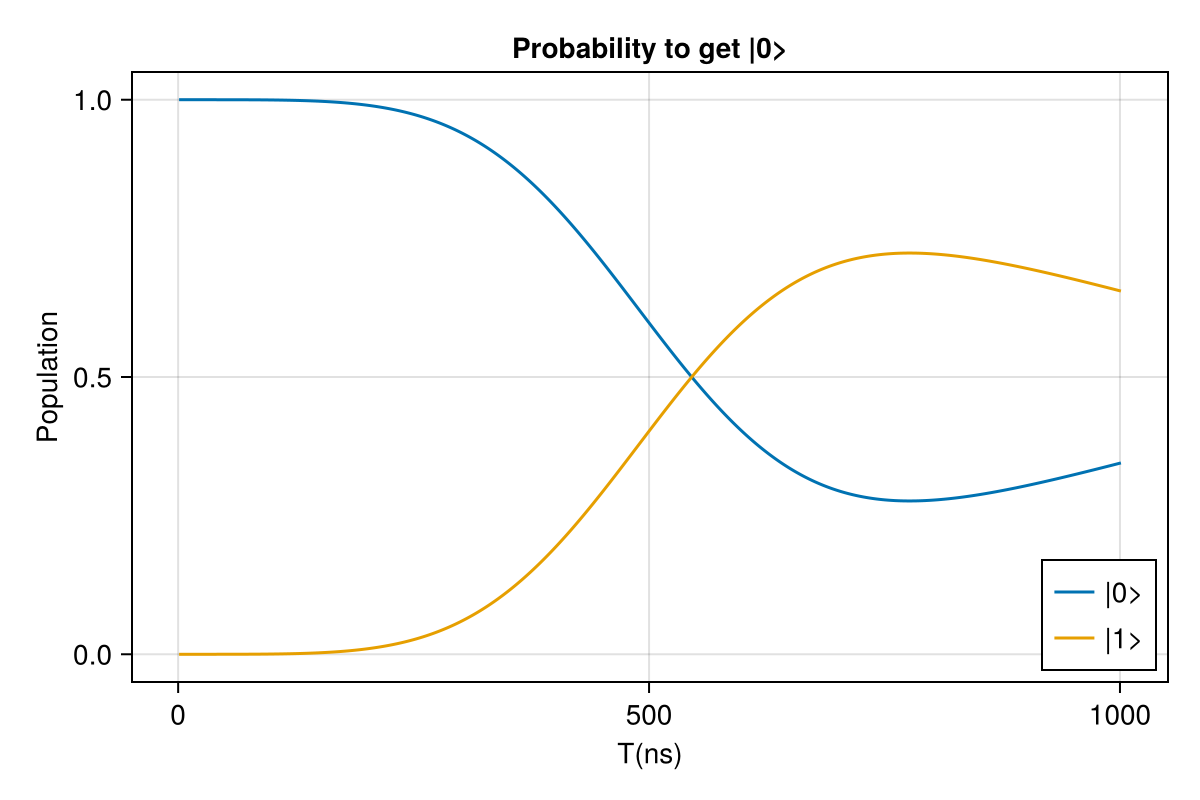

CairoMakie.Screen{IMAGE}


In [24]:
Tg = 100
T1 = 150
Tϕ = 100
res = result(Tg, 1)

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0>", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, res[2], label = "|0>")
lines!(ax, res[3], label = "|1>")
axislegend(ax; position = :rb)
display(fig)

In [16]:
Tg = 10
T1 = 150 #* 10
Tϕ = 100 #* 10

100

In [24]:
inf = []
for i in range(1, 3; step = 1)
    Tg = i

    T1 = 15 #* 10
    Tϕ = 10 #* 10
    time = 10^2
    t_span = (0.0, time)
    prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    sol = solve(prob, Tsit5(), dt = 0.1)
    states = sol.u
    push!(inf, calc_infidelity(states))
end

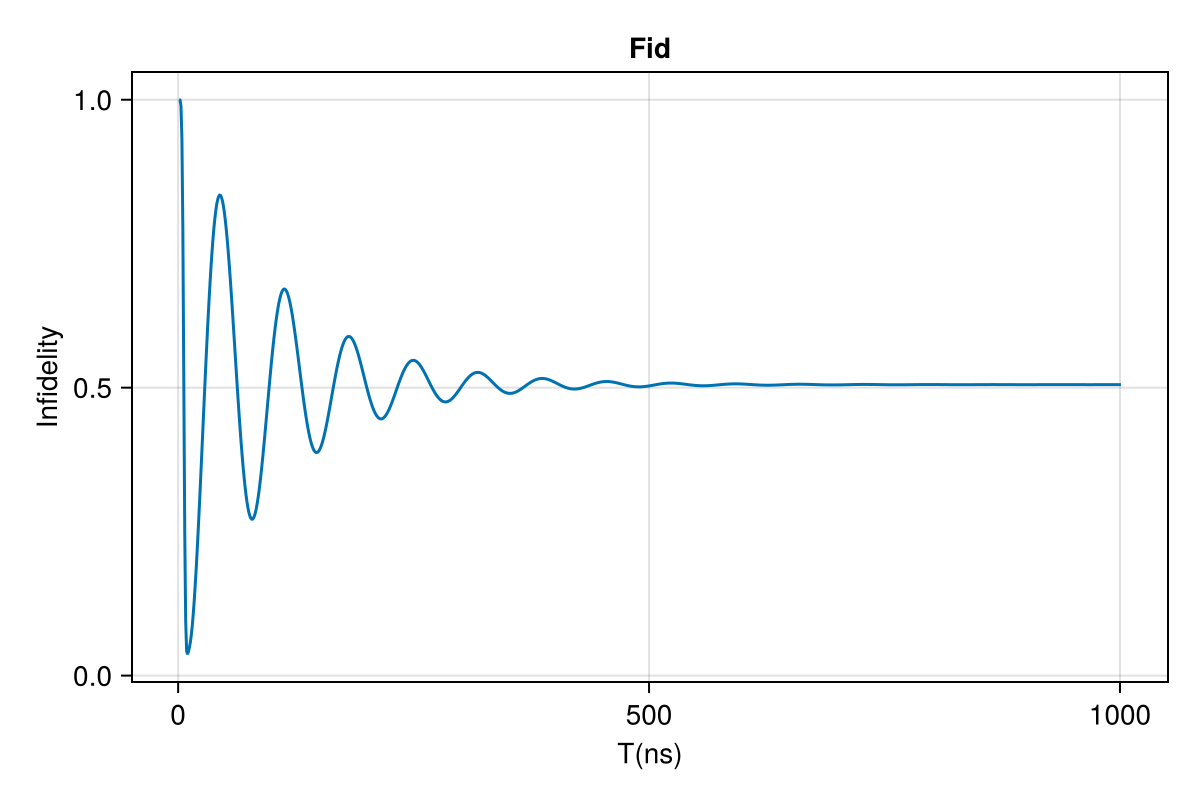

CairoMakie.Screen{IMAGE}


In [25]:

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Fid", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, inf[1])
display(fig)

In [30]:
T1 = 150 #* 10#^3
Tϕ = 100 #* 10#^3
time = 10^3
step_size = time * 10^-2

function calc_final_infidelity(t, chooser)
    return 1 - Uhlmann_Fidelity(target_ρ,result(t, chooser)[1][end])
end

final_fids = []
for i in range(1, time; step = step_size)
    push!(final_fids, calc_final_infidelity(i, 1))
end

final_fids_DRAG = []
for i in range(1, time; step = step_size)
    push!(final_fids, calc_final_infidelity(i, 2))
end

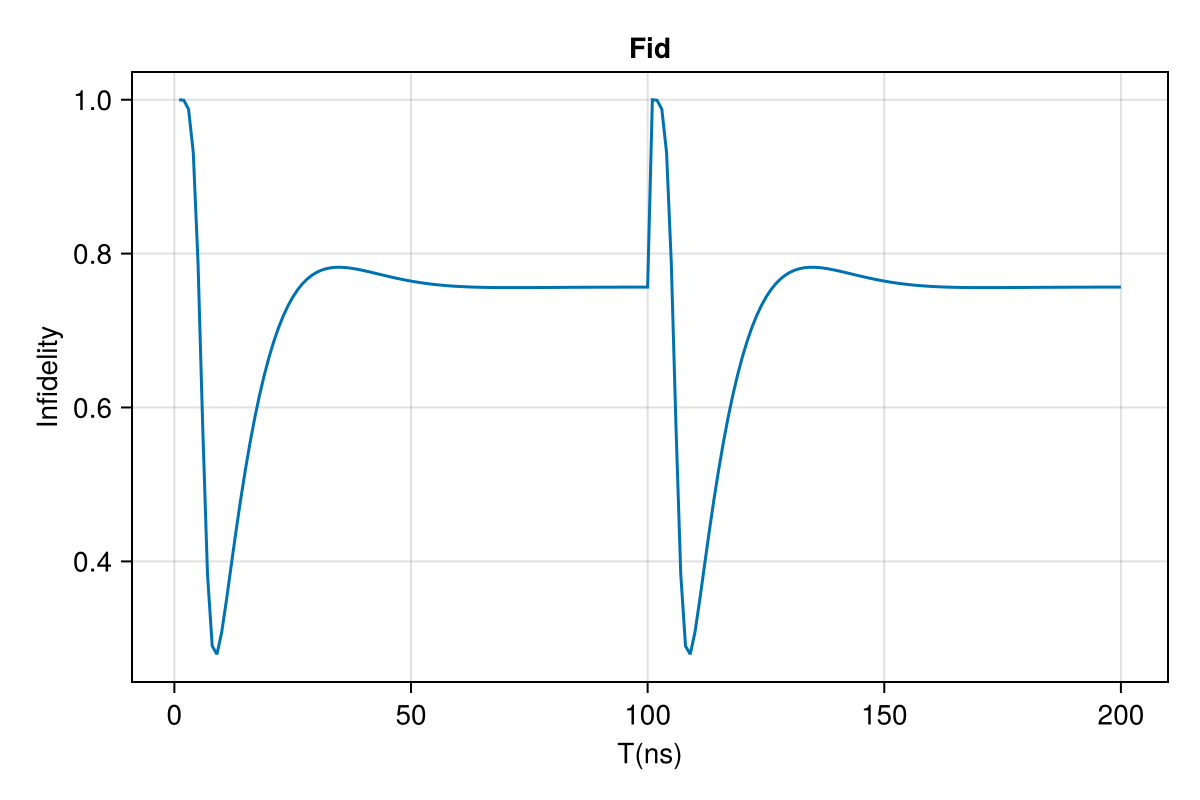

CairoMakie.Screen{IMAGE}


In [31]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Fid", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, final_fids)
#lines!(ax, final_fids_DRAG)
display(fig)

In [32]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
DELTA = - 2π * 400 / 1000

function gaussian_curve(T, N)
    A = π / (T * (super_duper_value - ℯ^(-2))) / 2
    μ = T / 2
    σ = T / 4

    times = collect(range(0, T, length = N))
    
    function f(t)
        return A * (ℯ^(-(t - μ)^2 / (2σ^2)) - ℯ^(-2))
    end

    function f_prime(t)
        return A * ℯ^(-(t - μ)^2 / (2σ^2)) * ((μ - t)/σ^2)
    end

    E_π = f.(times)
    Ė_π = f_prime.(times)
    return times, E_π, Ė_π
end

function drag_gaussian(T, N)
    times, E_π, Ė_π = gaussian_curve(T, N)
    E_x = E_π .+ ((λ^2-4)/(8DELTA^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128DELTA^4 * E_π .^ 5)
    E_y = -Ė_π ./ DELTA + ((33(λ^2-2)/24DELTA^3) * E_π .^2 .* Ė_π)
    return times, E_x, E_y
end

drag_gaussian (generic function with 2 methods)

In [ ]:
N = 100
function test_fidelity(t)
    fids = []
    for i in result(t,1)[1]
        push!(fids, Uhlmann_Fidelity(result(t,1)[1][i]))
    return fids
    end
end


function test_gaussian(T)
    controls = zeros(2, N)
    times, gaussian, _ = gaussian_curve(T, N)
    controls[1, :] .= gaussian
    return test_fidelity(T)
end

test_gaussian (generic function with 1 method)

In [43]:
Ts = 1.0:5.0:150.0
gaussian_fidelities = zeros(length(Ts))
for (i, t_g) in enumerate(Ts)
    gaussian_fidelities[i] = test_gaussian(t_g)
end

ArgumentError: ArgumentError: unable to check bounds for indices of type ComplexF64